In [ ]:
import math
import platform
import tempfile
import time
import urllib.request
import warnings
import zipfile
from itertools import product
from pathlib import Path
import numpy as np
import pandas as pd
import scipy
import sklearn
import xgboost
import xgboost as xgb
from scipy.stats import t as student_t
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    auc,
    confusion_matrix,
    matthews_corrcoef,
    precision_recall_curve,
)
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
warnings.filterwarnings("ignore")
SEED = 42
OUTER_FOLDS = 5
OUTER_REPEATS = 5
INNER_FOLDS = 3
ROUNDS = 200
DEPTHS = [2, 3]
LEARNING_RATES = [0.05, 0.10]
WEIGHTED_ALPHAS = [1.5, 2.0, 2.5, 3.0, 4.0]
BALANCE_BETAS = [0.90, 0.99, 0.999]
METHODS = [
    "XGB",
    "Class-XGB",
    "SPW-XGB",
    "Weighted-XGB",
    "CB-XGB",
    "CMPSW",
]
METRICS = [
    "AUC_PR",
    "MCC",
    "G_Mean",
    "Sensitivity",
]
OUTPUT_DIR = Path("/content/drive/MyDrive/CMPSW_CODE_V1")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
def download(url, path):
    urllib.request.urlretrieve(url, path)
def clean_data(data):
    data = data.copy()
    data.columns = [str(column).strip() for column in data.columns]
    data = data.replace(r"^\s*$", np.nan, regex=True)
    for column in data.columns:
        if data[column].dtype == object:
            converted = pd.to_numeric(data[column], errors="coerce")
            if converted.notna().sum() == data[column].notna().sum():
                data[column] = converted
    return data
def load_z_alizadeh(folder):
    url = (
        "https://archive.ics.uci.edu/static/public/412/"
        "z%2Balizadeh%2Bsani.zip"
    )
    archive = folder / "z_alizadeh.zip"
    extracted = folder / "z_alizadeh"
    download(url, archive)
    with zipfile.ZipFile(archive) as file:
        file.extractall(extracted)
    files = list(extracted.rglob("*.xlsx"))
    if not files:
        raise FileNotFoundError("Z-Alizadeh Sani dataset not found.")
    data = clean_data(pd.read_excel(files[0]))
    target = next(
        column
        for column in data.columns
        if column.lower() == "cath"
    )
    labels = (
        data[target]
        .astype(str)
        .str.strip()
        .str.upper()
        .map({
            "CAD": 1,
            "NORMAL": 0,
        })
    )
    valid = labels.notna()
    features = (
        data.loc[valid]
        .drop(columns=[target])
        .reset_index(drop=True)
    )
    labels = (
        labels.loc[valid]
        .astype(int)
        .to_numpy()
    )
    return features, labels
def load_heart_failure(folder):
    url = (
        "https://archive.ics.uci.edu/ml/"
        "machine-learning-databases/00519/"
        "heart_failure_clinical_records_dataset.csv"
    )
    path = folder / "heart_failure.csv"
    download(url, path)
    data = clean_data(pd.read_csv(path))
    labels = pd.to_numeric(
        data["DEATH_EVENT"],
        errors="coerce",
    )
    valid = labels.notna()
    features = (
        data.loc[valid]
        .drop(
            columns=[
                "DEATH_EVENT",
                "time",
            ],
            errors="ignore",
        )
        .reset_index(drop=True)
    )
    labels = (
        labels.loc[valid]
        .astype(int)
        .to_numpy()
    )
    return features, labels
def load_long_beach(folder):
    url = (
        "https://archive.ics.uci.edu/ml/"
        "machine-learning-databases/heart-disease/"
        "processed.va.data"
    )
    path = folder / "long_beach.data"
    download(url, path)
    columns = [
        "age",
        "sex",
        "cp",
        "trestbps",
        "chol",
        "fbs",
        "restecg",
        "thalach",
        "exang",
        "oldpeak",
        "slope",
        "ca",
        "thal",
        "target",
    ]
    data = pd.read_csv(
        path,
        header=None,
        names=columns,
        na_values=["?"],
    )
    data = clean_data(data)
    target = pd.to_numeric(
        data["target"],
        errors="coerce",
    )
    valid = target.notna()
    data = (
        data.loc[valid]
        .reset_index(drop=True)
    )
    target = (
        target.loc[valid]
        .reset_index(drop=True)
    )
    features = data.drop(
        columns=[
            "target",
            "slope",
            "ca",
            "thal",
        ],
        errors="ignore",
    )
    labels = (
        target > 0
    ).astype(int).to_numpy()
    return features, labels
def detect_columns(features):
    numeric = []
    categorical = []
    for column in features.columns:
        values = features[column]
        if pd.api.types.is_numeric_dtype(values):
            observed = values.dropna()
            integer_like = (
                len(observed) > 0
                and np.allclose(
                    observed,
                    np.round(observed),
                )
            )
            if integer_like and observed.nunique() <= 10:
                categorical.append(column)
            else:
                numeric.append(column)
        else:
            categorical.append(column)
    return numeric, categorical
def encoder():
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            drop="if_binary",
            sparse_output=False,
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            drop="if_binary",
            sparse=False,
        )
def preprocessor(features):
    numeric, categorical = detect_columns(features)
    transformers = []
    if numeric:
        transformers.append(
            (
                "numeric",
                Pipeline([
                    (
                        "imputer",
                        SimpleImputer(strategy="median"),
                    ),
                    (
                        "scaler",
                        StandardScaler(),
                    ),
                ]),
                numeric,
            )
        )
    if categorical:
        transformers.append(
            (
                "categorical",
                Pipeline([
                    (
                        "imputer",
                        SimpleImputer(strategy="most_frequent"),
                    ),
                    (
                        "encoder",
                        encoder(),
                    ),
                ]),
                categorical,
            )
        )
    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
    )
def transform_data(train_features, test_features):
    processor = preprocessor(train_features)
    train_matrix = processor.fit_transform(train_features)
    test_matrix = processor.transform(test_features)
    return (
        np.asarray(train_matrix, dtype=np.float32),
        np.asarray(test_matrix, dtype=np.float32),
    )
def recode_minority(train_labels, test_labels):
    classes, counts = np.unique(
        train_labels,
        return_counts=True,
    )
    minority = classes[np.argmin(counts)]
    train_binary = (
        np.asarray(train_labels) == minority
    ).astype(np.int8)
    test_binary = (
        np.asarray(test_labels) == minority
    ).astype(np.int8)
    return train_binary, test_binary, int(minority)
def class_weights(labels):
    labels = np.asarray(labels, dtype=int)
    total = len(labels)
    counts = np.bincount(
        labels,
        minlength=2,
    )
    weights = np.ones(
        total,
        dtype=float,
    )
    for label in [0, 1]:
        if counts[label] > 0:
            weights[labels == label] = (
                total
                / (
                    2.0
                    * counts[label]
                )
            )
    return weights
def local_support(features, labels):
    labels = np.asarray(labels, dtype=int)
    total = len(labels)
    if total < 3:
        return np.ones(total, dtype=float), 1
    neighbours = min(
        max(
            1,
            math.ceil(math.sqrt(total)),
        ),
        total - 1,
    )
    model = NearestNeighbors(
        n_neighbors=neighbours + 1,
        metric="euclidean",
    )
    model.fit(features)
    indices = model.kneighbors(
        features,
        return_distance=False,
    )[:, 1:]
    support = np.mean(
        labels[indices]
        == labels[:, None],
        axis=1,
    )
    return support.astype(float), neighbours
def cmpsw_weights(features, labels):
    base = class_weights(labels)
    support, neighbours = local_support(
        features,
        labels,
    )
    adjusted = np.ones(
        len(labels),
        dtype=float,
    )
    means = {}
    for label in [0, 1]:
        mask = labels == label
        if not np.any(mask):
            means[label] = np.nan
            continue
        mean_support = float(
            np.mean(
                support[mask]
            )
        )
        means[label] = mean_support
        if mean_support > 0:
            adjusted[mask] = (
                support[mask]
                / mean_support
            )
    weights = base * adjusted
    expected = len(labels) / 2.0
    masses = {
        label: float(
            np.sum(
                weights[
                    labels == label
                ]
            )
        )
        for label in [0, 1]
    }
    for label in [0, 1]:
        if not np.isclose(
            masses[label],
            expected,
            rtol=1e-9,
            atol=1e-9,
        ):
            raise RuntimeError(
                "Class-mass preservation failed."
            )
    if not np.isclose(
        np.mean(weights),
        1.0,
        rtol=1e-9,
        atol=1e-9,
    ):
        raise RuntimeError(
            "Mean sample weight is not one."
        )
    return weights, support, neighbours, means, masses
def effective_weights(labels, beta):
    labels = np.asarray(labels, dtype=int)
    counts = np.bincount(
        labels,
        minlength=2,
    ).astype(float)
    values = np.ones(
        len(labels),
        dtype=float,
    )
    class_values = {}
    for label in [0, 1]:
        if counts[label] <= 0:
            class_values[label] = np.nan
            continue
        effective = (
            1.0
            - beta ** counts[label]
        ) / (
            1.0 - beta
        )
        class_values[label] = (
            1.0
            / effective
        )
        values[labels == label] = (
            class_values[label]
        )
    return values / np.mean(values)
def model_parameters(
    depth,
    learning_rate,
    seed,
    positive_weight=1.0,
):
    return {
        "objective": "binary:logistic",
        "eval_metric": "aucpr",
        "max_depth": depth,
        "eta": learning_rate,
        "min_child_weight": 1.0,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
        "lambda": 1.0,
        "alpha": 0.0,
        "scale_pos_weight": positive_weight,
        "tree_method": "hist",
        "seed": seed,
        "nthread": -1,
        "verbosity": 0,
    }
def fit_model(
    features,
    labels,
    depth,
    learning_rate,
    seed,
    sample_weight=None,
    positive_weight=1.0,
):
    training = xgb.DMatrix(
        features,
        label=labels,
        weight=sample_weight,
    )
    return xgb.train(
        model_parameters(
            depth,
            learning_rate,
            seed,
            positive_weight,
        ),
        training,
        num_boost_round=ROUNDS,
        verbose_eval=False,
    )
def predict(model, features):
    return model.predict(
        xgb.DMatrix(features)
    )
def evaluate(labels, probabilities):
    probabilities = np.asarray(
        probabilities,
        dtype=float,
    )
    predictions = (
        probabilities >= 0.5
    ).astype(int)
    auc_pr = auc_pr_score(
        labels,
        probabilities,
    )
    mcc = matthews_corrcoef(
        labels,
        predictions,
    )
    tn, fp, fn, tp = confusion_matrix(
        labels,
        predictions,
        labels=[0, 1],
    ).ravel()
    sensitivity = (
        tp / (tp + fn)
        if tp + fn > 0
        else np.nan
    )
    specificity = (
        tn / (tn + fp)
        if tn + fp > 0
        else np.nan
    )
    return {
        "AUC_PR": auc_pr,
        "MCC": mcc,
        "G_Mean": np.sqrt(
            sensitivity * specificity
        ),
        "Sensitivity": sensitivity,
    }
def auc_pr_score(labels, probabilities):
    precision, recall, _ = precision_recall_curve(
        labels,
        probabilities,
    )
    return float(
        auc(
            recall,
            precision,
        )
    )
def configurations(method):
    base = list(
        product(
            DEPTHS,
            LEARNING_RATES,
        )
    )
    rows = []
    for depth, learning_rate in base:
        if method == "Weighted-XGB":
            for alpha in WEIGHTED_ALPHAS:
                rows.append({
                    "depth": depth,
                    "learning_rate": learning_rate,
                    "alpha": alpha,
                    "beta": np.nan,
                })
        elif method == "CB-XGB":
            for beta in BALANCE_BETAS:
                rows.append({
                    "depth": depth,
                    "learning_rate": learning_rate,
                    "alpha": np.nan,
                    "beta": beta,
                })
        else:
            rows.append({
                "depth": depth,
                "learning_rate": learning_rate,
                "alpha": np.nan,
                "beta": np.nan,
            })
    return rows
def training_setup(
    method,
    features,
    labels,
    setting,
):
    weight = None
    positive_weight = 1.0
    diagnostics = {}
    if method == "Class-XGB":
        weight = class_weights(labels)
    elif method == "SPW-XGB":
        counts = np.bincount(
            labels,
            minlength=2,
        )
        positive_weight = (
            counts[0] / counts[1]
            if counts[1] > 0
            else 1.0
        )
    elif method == "Weighted-XGB":
        positive_weight = float(
            setting["alpha"]
        )
    elif method == "CB-XGB":
        weight = effective_weights(
            labels,
            float(
                setting["beta"]
            ),
        )
    elif method == "CMPSW":
        (
            weight,
            support,
            neighbours,
            means,
            masses,
        ) = cmpsw_weights(
            features,
            labels,
        )
        diagnostics = {
            "Neighbour_Count":
                neighbours,
            "Mean_Support":
                float(
                    np.mean(support)
                ),
            "Majority_Support":
                means[0],
            "Minority_Support":
                means[1],
            "Majority_Mass":
                masses[0],
            "Minority_Mass":
                masses[1],
        }
    return (
        weight,
        positive_weight,
        diagnostics,
    )
def tune_method(
    method,
    features,
    labels,
    seed,
):
    splitter = StratifiedKFold(
        n_splits=INNER_FOLDS,
        shuffle=True,
        random_state=seed,
    )
    splits = list(
        splitter.split(
            features,
            labels,
        )
    )
    best_setting = None
    best_score = -np.inf
    for setting in configurations(method):
        scores = []
        for inner_fold, (
            train_index,
            valid_index,
        ) in enumerate(
            splits,
            start=1,
        ):
            train_features = (
                features.iloc[train_index]
                .reset_index(drop=True)
            )
            valid_features = (
                features.iloc[valid_index]
                .reset_index(drop=True)
            )
            train_labels = labels[
                train_index
            ]
            valid_labels = labels[
                valid_index
            ]
            (
                train_matrix,
                valid_matrix,
            ) = transform_data(
                train_features,
                valid_features,
            )
            (
                weight,
                positive_weight,
                _,
            ) = training_setup(
                method,
                train_matrix,
                train_labels,
                setting,
            )
            model = fit_model(
                train_matrix,
                train_labels,
                setting["depth"],
                setting["learning_rate"],
                seed + inner_fold,
                weight,
                positive_weight,
            )
            probabilities = predict(
                model,
                valid_matrix,
            )
            scores.append(
                auc_pr_score(
                    valid_labels,
                    probabilities,
                )
            )
        score = float(
            np.mean(scores)
        )
        if score > best_score + 1e-12:
            best_score = score
            best_setting = setting.copy()
    best_setting["inner_auc_pr"] = best_score
    return best_setting
def dataset_profile(name, features, labels):
    counts = pd.Series(
        labels
    ).value_counts()
    minority = int(
        counts.idxmin()
    )
    majority = int(
        counts.idxmax()
    )
    return {
        "Dataset": name,
        "Samples": len(labels),
        "Features": features.shape[1],
        "Majority_Label": majority,
        "Minority_Label": minority,
        "Majority_N": int(
            counts.loc[majority]
        ),
        "Minority_N": int(
            counts.loc[minority]
        ),
        "Imbalance_Ratio": (
            counts.loc[majority]
            / counts.loc[minority]
        ),
    }
def run_dataset(name, features, labels):
    splitter = RepeatedStratifiedKFold(
        n_splits=OUTER_FOLDS,
        n_repeats=OUTER_REPEATS,
        random_state=SEED,
    )
    results = []
    parameters = []
    for split_number, (
        train_index,
        test_index,
    ) in enumerate(
        splitter.split(
            features,
            labels,
        )
    ):
        repeat = (
            split_number
            // OUTER_FOLDS
            + 1
        )
        fold = (
            split_number
            % OUTER_FOLDS
            + 1
        )
        train_features = (
            features.iloc[train_index]
            .reset_index(drop=True)
        )
        test_features = (
            features.iloc[test_index]
            .reset_index(drop=True)
        )
        raw_train_labels = labels[
            train_index
        ]
        raw_test_labels = labels[
            test_index
        ]
        (
            train_labels,
            test_labels,
            minority_label,
        ) = recode_minority(
            raw_train_labels,
            raw_test_labels,
        )
        seed = (
            SEED
            + repeat * 10000
            + fold * 100
        )
        (
            train_matrix,
            test_matrix,
        ) = transform_data(
            train_features,
            test_features,
        )
        for method in METHODS:
            setting = tune_method(
                method,
                train_features,
                train_labels,
                seed,
            )
            (
                weight,
                positive_weight,
                diagnostics,
            ) = training_setup(
                method,
                train_matrix,
                train_labels,
                setting,
            )
            start = time.perf_counter()
            model = fit_model(
                train_matrix,
                train_labels,
                setting["depth"],
                setting["learning_rate"],
                seed,
                weight,
                positive_weight,
            )
            fit_ms = (
                time.perf_counter()
                - start
            ) * 1000.0
            start = time.perf_counter()
            probabilities = predict(
                model,
                test_matrix,
            )
            predict_ms = (
                time.perf_counter()
                - start
            ) * 1000.0
            scores = evaluate(
                test_labels,
                probabilities,
            )
            results.append({
                "Dataset": name,
                "Repeat": repeat,
                "Fold": fold,
                "Method": method,
                "Minority_Raw_Label":
                    minority_label,
                "Train_N":
                    len(train_labels),
                "Test_N":
                    len(test_labels),
                **scores,
                "Fit_ms":
                    fit_ms,
                "Predict_ms":
                    predict_ms,
                **diagnostics,
            })
            parameters.append({
                "Dataset": name,
                "Repeat": repeat,
                "Fold": fold,
                "Method": method,
                "Depth":
                    setting["depth"],
                "Learning_Rate":
                    setting[
                        "learning_rate"
                    ],
                "Alpha":
                    setting["alpha"],
                "Beta":
                    setting["beta"],
                "Inner_AUC_PR":
                    setting[
                        "inner_auc_pr"
                    ],
                "Positive_Weight":
                    positive_weight,
            })
    return (
        pd.DataFrame(results),
        pd.DataFrame(parameters),
    )
def result_summary(results):
    rows = []
    for (
        dataset,
        method,
    ), group in results.groupby(
        [
            "Dataset",
            "Method",
        ],
        sort=False,
    ):
        row = {
            "Dataset": dataset,
            "Method": method,
        }
        for metric in METRICS:
            row[
                f"{metric}_Mean"
            ] = group[
                metric
            ].mean()
            row[
                f"{metric}_SD"
            ] = group[
                metric
            ].std(ddof=1)
        row["Fit_ms_Mean"] = (
            group["Fit_ms"].mean()
        )
        row["Predict_ms_Mean"] = (
            group[
                "Predict_ms"
            ].mean()
        )
        rows.append(row)
    summary = pd.DataFrame(rows)
    summary["Method"] = pd.Categorical(
        summary["Method"],
        categories=METHODS,
        ordered=True,
    )
    return (
        summary
        .sort_values(
            [
                "Dataset",
                "Method",
            ]
        )
        .reset_index(drop=True)
    )
def overall_summary(results):
    dataset_means = (
        results
        .groupby(
            [
                "Dataset",
                "Method",
            ],
            as_index=False,
        )[METRICS]
        .mean()
    )
    overall = (
        dataset_means
        .groupby(
            "Method"
        )[METRICS]
        .mean()
        .reindex(METHODS)
        .reset_index()
    )
    return overall
def pairwise_comparison(results):
    pivot = results.pivot_table(
        index=[
            "Dataset",
            "Repeat",
            "Fold",
        ],
        columns="Method",
        values=METRICS,
    )
    rows = []
    for reference in METHODS:
        if reference == "CMPSW":
            continue
        for metric in METRICS:
            difference = (
                pivot[
                    (
                        metric,
                        "CMPSW",
                    )
                ]
                - pivot[
                    (
                        metric,
                        reference,
                    )
                ]
            )
            rows.append({
                "Reference": reference,
                "Metric": metric,
                "Mean_Delta":
                    difference.mean(),
                "Wins":
                    int(
                        (
                            difference > 0
                        ).sum()
                    ),
                "Ties":
                    int(
                        np.isclose(
                            difference,
                            0,
                        )
                        .sum()
                    ),
                "Losses":
                    int(
                        (
                            difference < 0
                        ).sum()
                    ),
            })
    return pd.DataFrame(rows)
def corrected_test(values):
    values = np.asarray(
        values,
        dtype=float,
    )
    values = values[
        np.isfinite(values)
    ]
    total = len(values)
    if total < 2:
        return (
            np.nan,
            np.nan,
            np.nan,
            np.nan,
        )
    mean = float(
        np.mean(values)
    )
    variance = float(
        np.var(
            values,
            ddof=1,
        )
    )
    correction = (
        1.0 / total
        + 1.0
        / (
            OUTER_FOLDS - 1
        )
    )
    standard_error = math.sqrt(
        correction
        * variance
    )
    if standard_error == 0:
        return (
            mean,
            np.nan,
            np.nan,
            np.nan,
        )
    statistic = (
        mean
        / standard_error
    )
    degrees = total - 1
    p_value = (
        2.0
        * student_t.sf(
            abs(statistic),
            df=degrees,
        )
    )
    critical = student_t.ppf(
        0.975,
        df=degrees,
    )
    lower = (
        mean
        - critical
        * standard_error
    )
    upper = (
        mean
        + critical
        * standard_error
    )
    return (
        mean,
        statistic,
        p_value,
        lower,
        upper,
    )
def holm_adjust(values):
    values = np.asarray(
        values,
        dtype=float,
    )
    adjusted = np.full(
        len(values),
        np.nan,
    )
    valid = np.where(
        np.isfinite(values)
    )[0]
    if len(valid) == 0:
        return adjusted
    order = valid[
        np.argsort(
            values[valid]
        )
    ]
    previous = 0.0
    total = len(order)
    for rank, index in enumerate(order):
        value = min(
            1.0,
            (
                total - rank
            )
            * values[index],
        )
        value = max(
            value,
            previous,
        )
        adjusted[index] = value
        previous = value
    return adjusted
def statistical_tests(results):
    pivot = results.pivot_table(
        index=[
            "Dataset",
            "Repeat",
            "Fold",
        ],
        columns="Method",
        values=METRICS,
    )
    rows = []
    datasets = (
        results["Dataset"]
        .drop_duplicates()
        .tolist()
    )
    for dataset in datasets:
        data = pivot.loc[
            dataset
        ]
        for reference in METHODS:
            if reference == "CMPSW":
                continue
            for metric in METRICS:
                difference = (
                    data[
                        (
                            metric,
                            "CMPSW",
                        )
                    ]
                    - data[
                        (
                            metric,
                            reference,
                        )
                    ]
                ).to_numpy()
                (
                    mean,
                    statistic,
                    p_value,
                    lower,
                    upper,
                ) = corrected_test(
                    difference
                )
                rows.append({
                    "Dataset":
                        dataset,
                    "Reference":
                        reference,
                    "Metric":
                        metric,
                    "Mean_Delta":
                        mean,
                    "Statistic":
                        statistic,
                    "P_Value":
                        p_value,
                    "CI95_Lower":
                        lower,
                    "CI95_Upper":
                        upper,
                })
    tests = pd.DataFrame(rows)
    tests["P_Holm"] = np.nan
    for dataset in datasets:
        mask = (
            tests["Dataset"]
            == dataset
        )
        tests.loc[
            mask,
            "P_Holm",
        ] = holm_adjust(
            tests.loc[
                mask,
                "P_Value",
            ].to_numpy()
        )
    return tests
def formatted_summary(summary):
    rows = []
    for _, row in summary.iterrows():
        rows.append({
            "Dataset":
                row["Dataset"],
            "Method":
                row["Method"],
            "AUC_PR":
                f"{row['AUC_PR_Mean']:.3f} ± "
                f"{row['AUC_PR_SD']:.3f}",
            "MCC":
                f"{row['MCC_Mean']:.3f} ± "
                f"{row['MCC_SD']:.3f}",
            "G_Mean":
                f"{row['G_Mean_Mean']:.3f} ± "
                f"{row['G_Mean_SD']:.3f}",
            "Sensitivity":
                f"{row['Sensitivity_Mean']:.3f} ± "
                f"{row['Sensitivity_SD']:.3f}",
        })
    return pd.DataFrame(rows)
def software_versions():
    return pd.DataFrame([
        {
            "Software": "Python",
            "Version": platform.python_version(),
        },
        {
            "Software": "NumPy",
            "Version": np.__version__,
        },
        {
            "Software": "pandas",
            "Version": pd.__version__,
        },
        {
            "Software": "scikit-learn",
            "Version": sklearn.__version__,
        },
        {
            "Software": "SciPy",
            "Version": scipy.__version__,
        },
        {
            "Software": "XGBoost",
            "Version": xgboost.__version__,
        },
    ])
with tempfile.TemporaryDirectory() as temporary:
    folder = Path(temporary)
    datasets = {
        "Z-Alizadeh Sani":
            load_z_alizadeh(
                folder
            ),
        "Heart Failure":
            load_heart_failure(
                folder
            ),
        "Long Beach VA":
            load_long_beach(
                folder
            ),
    }
    profiles = []
    result_frames = []
    parameter_frames = []
    for name, (
        features,
        labels,
    ) in datasets.items():
        profiles.append(
            dataset_profile(
                name,
                features,
                labels,
            )
        )
        (
            result_data,
            parameter_data,
        ) = run_dataset(
            name,
            features,
            labels,
        )
        result_frames.append(
            result_data
        )
        parameter_frames.append(
            parameter_data
        )
results = pd.concat(
    result_frames,
    ignore_index=True,
)
parameters = pd.concat(
    parameter_frames,
    ignore_index=True,
)
profiles = pd.DataFrame(
    profiles
)
summary = result_summary(
    results
)
overall = overall_summary(
    results
)
comparisons = pairwise_comparison(
    results
)
tests = statistical_tests(
    results
)
versions = software_versions()
display_summary = formatted_summary(
    summary
)
display_summary.to_csv(
    OUTPUT_DIR / "metrics_Results.csv",
    index=False,
)
profiles.to_csv(
    OUTPUT_DIR
    / "dataset_profile.csv",
    index=False,
)
results.to_csv(
    OUTPUT_DIR
    / "fold_metrics.csv",
    index=False,
)
summary.to_csv(
    OUTPUT_DIR
    / "metric_summary.csv",
    index=False,
)
overall.to_csv(
    OUTPUT_DIR
    / "overall_metrics.csv",
    index=False,
)
comparisons.to_csv(
    OUTPUT_DIR
    / "pairwise_metrics.csv",
    index=False,
)
tests.to_csv(
    OUTPUT_DIR
    / "statistical_tests.csv",
    index=False,
)
parameters.to_csv(
    OUTPUT_DIR
    / "selected_parameters.csv",
    index=False,
)
versions.to_csv(
    OUTPUT_DIR
    / "software_versions.csv",
    index=False,
)
print(
    display_summary.to_string(
        index=False
    )
)
print()
print(
    overall.round(3).to_string(
        index=False
    )
)
print()
print(
    comparisons.round(3).to_string(
        index=False
    )
)
print()
print(
    tests.round(4).to_string(
        index=False
    )
)
print()
print(
    profiles.round(3).to_string(
        index=False
    )
)
print()
print(
    OUTPUT_DIR
)

        Dataset       Method        AUC_PR           MCC        G_Mean   Sensitivity
  Heart Failure          XGB 0.629 ± 0.104 0.384 ± 0.152 0.649 ± 0.096 0.500 ± 0.138
  Heart Failure    Class-XGB 0.632 ± 0.107 0.411 ± 0.127 0.706 ± 0.075 0.655 ± 0.122
  Heart Failure      SPW-XGB 0.636 ± 0.106 0.427 ± 0.114 0.713 ± 0.068 0.665 ± 0.122
  Heart Failure Weighted-XGB 0.634 ± 0.106 0.399 ± 0.112 0.693 ± 0.073 0.653 ± 0.155
  Heart Failure       CB-XGB 0.632 ± 0.102 0.400 ± 0.134 0.684 ± 0.085 0.586 ± 0.138
  Heart Failure        CMPSW 0.653 ± 0.116 0.453 ± 0.137 0.720 ± 0.077 0.640 ± 0.113
  Long Beach VA          XGB 0.442 ± 0.126 0.179 ± 0.162 0.443 ± 0.141 0.244 ± 0.126
  Long Beach VA    Class-XGB 0.427 ± 0.130 0.128 ± 0.178 0.519 ± 0.154 0.397 ± 0.170
  Long Beach VA      SPW-XGB 0.435 ± 0.123 0.176 ± 0.186 0.546 ± 0.131 0.412 ± 0.173
  Long Beach VA Weighted-XGB 0.446 ± 0.122 0.177 ± 0.179 0.513 ± 0.130 0.349 ± 0.156
  Long Beach VA       CB-XGB 0.431 ± 0.129 0.149 ± 0.176 0.492 ± 

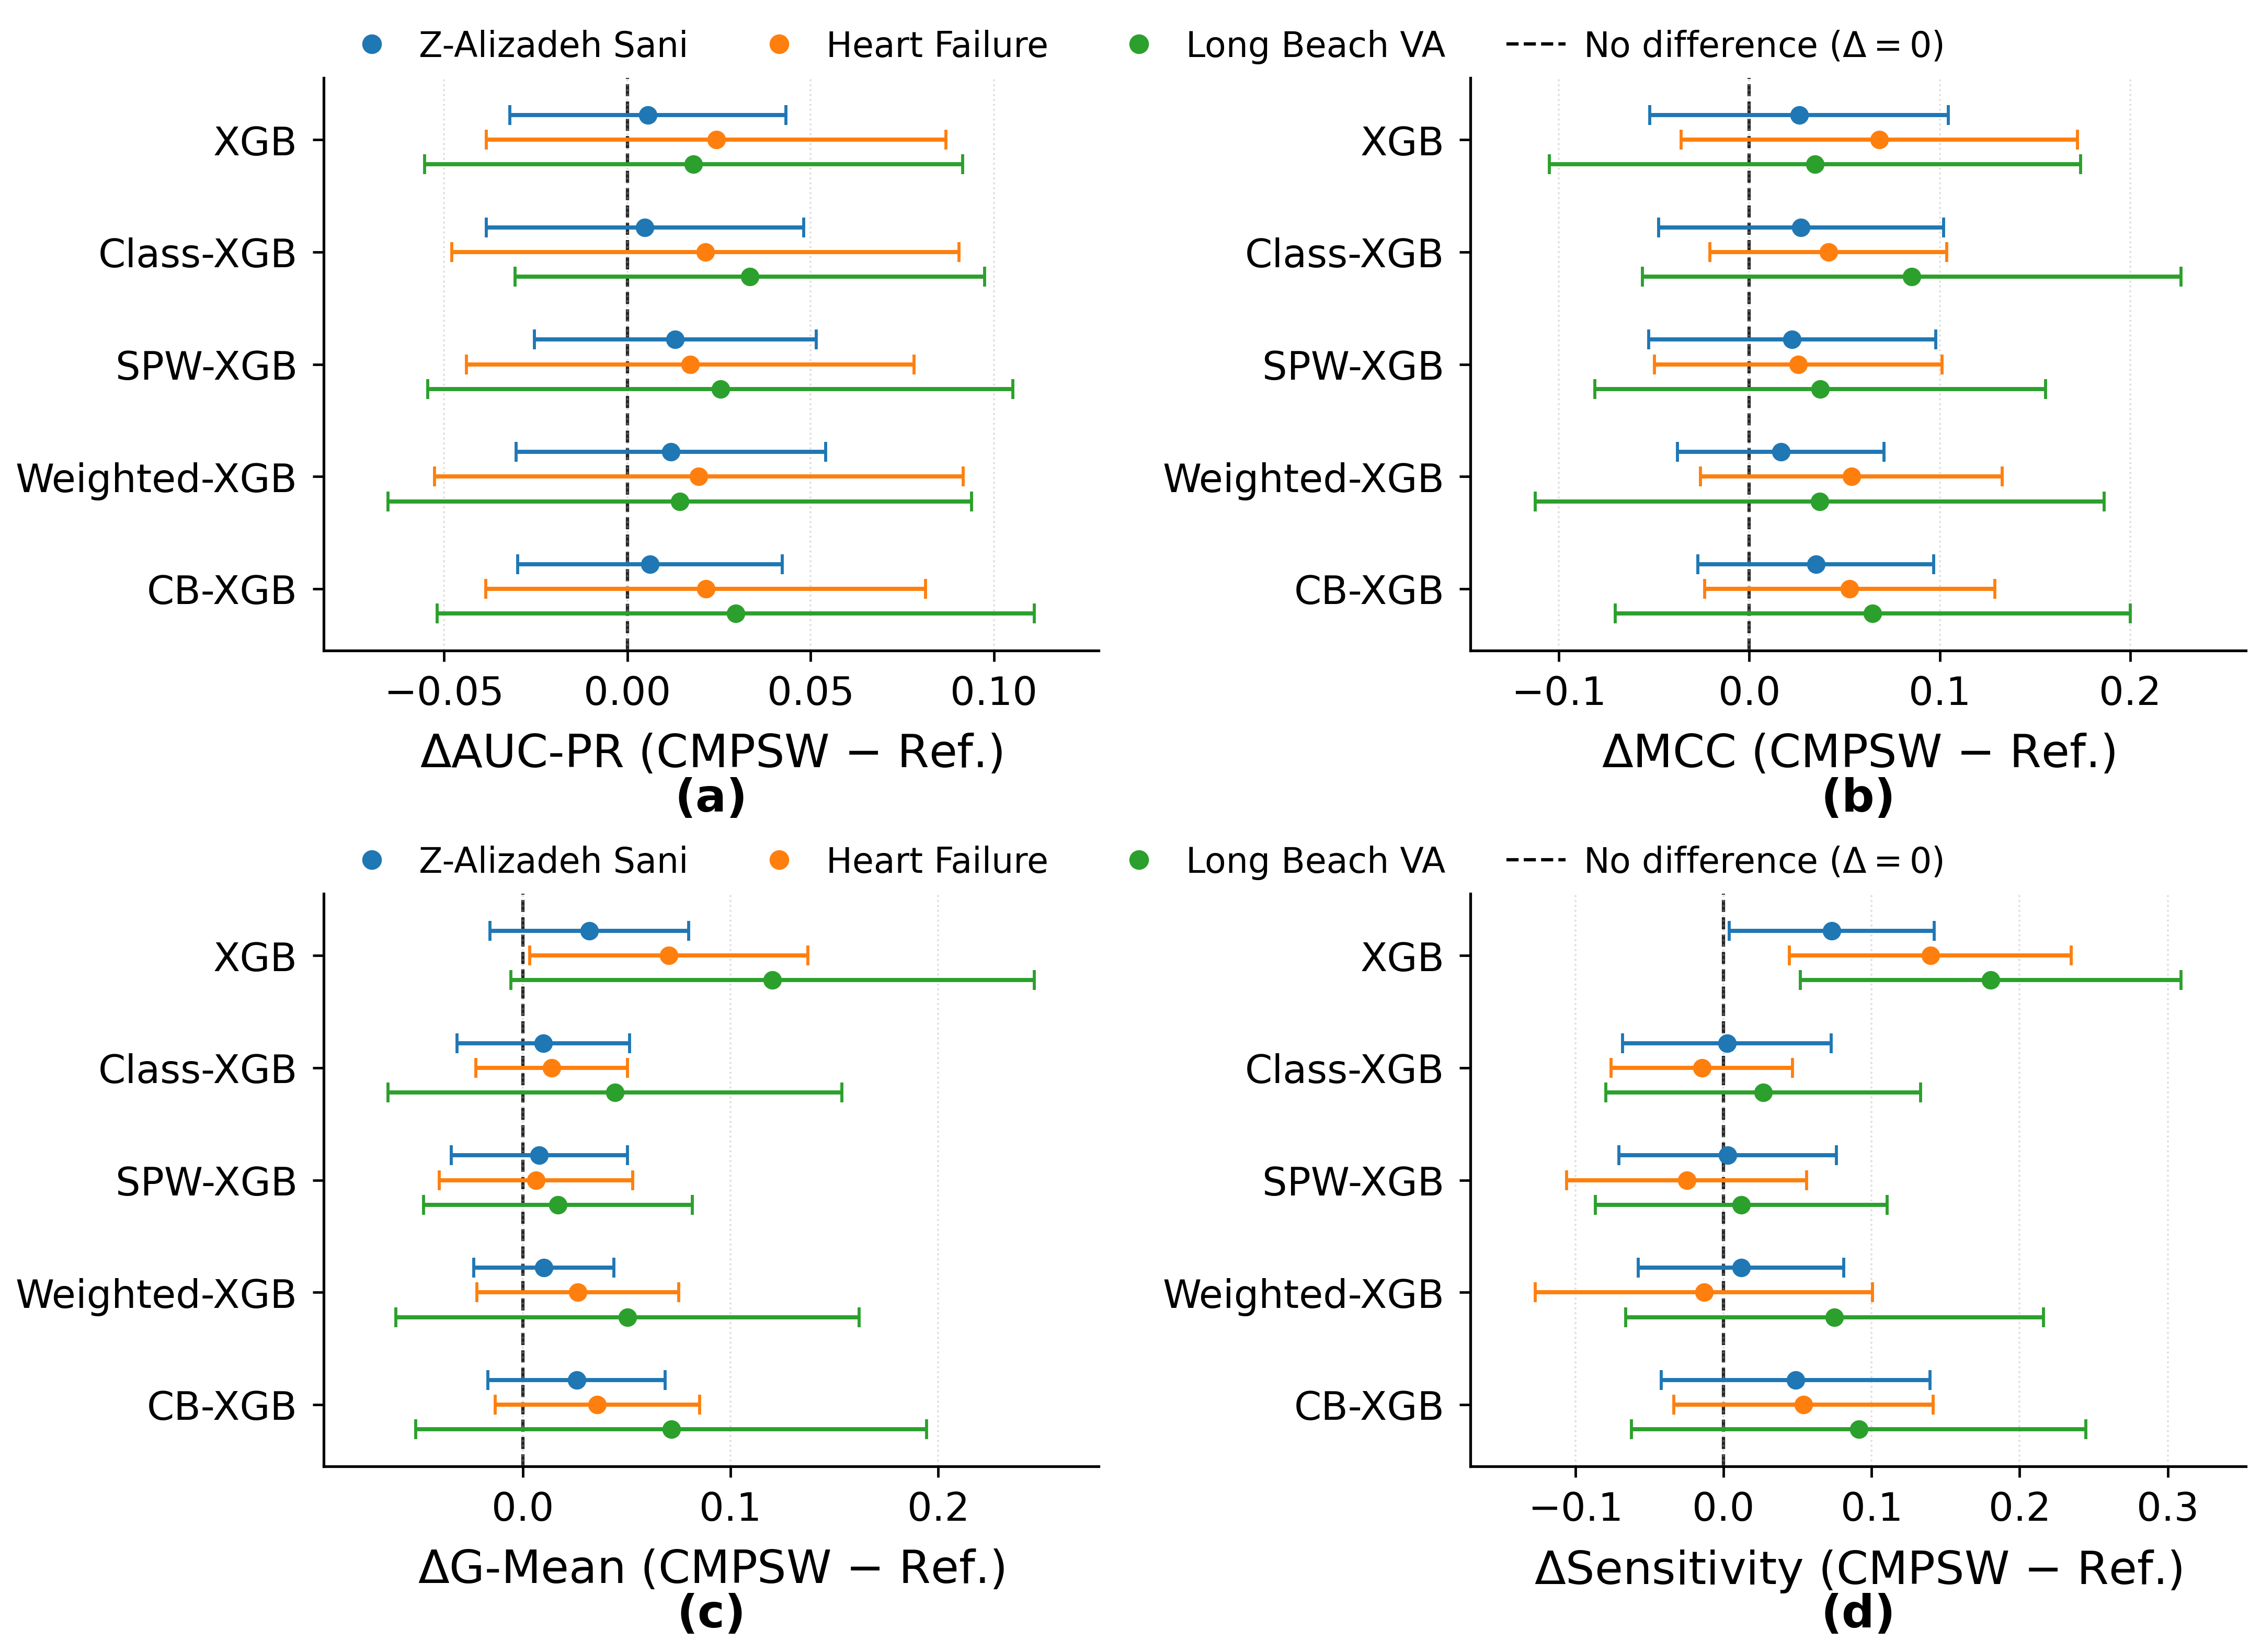

/content/drive/MyDrive/CMPSW_CODE_V1/figures/Combined_Effect_Size_Estimation.png


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


DATA_FILE = Path(
    "/content/drive/MyDrive/CMPSW_CODE_V1/statistical_tests.csv"
)

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/CMPSW_CODE_V1/figures"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DATASETS = [
    "Z-Alizadeh Sani",
    "Heart Failure",
    "Long Beach VA",
]

REFERENCES = [
    "XGB",
    "Class-XGB",
    "SPW-XGB",
    "Weighted-XGB",
    "CB-XGB",
]

METRICS = {
    "AUC_PR": "AUC-PR",
    "MCC": "MCC",
    "G_Mean": "G-Mean",
    "Sensitivity": "Sensitivity",
}

X_LABELS = {
    "AUC_PR": r"$\Delta$AUC-PR (CMPSW $-$ Ref.)",
    "MCC": r"$\Delta$MCC (CMPSW $-$ Ref.)",
    "G_Mean": r"$\Delta$G-Mean (CMPSW $-$ Ref.)",
    "Sensitivity": r"$\Delta$Sensitivity (CMPSW $-$ Ref.)",
}

PANEL_LABELS = [
    "(a)",
    "(b)",
    "(c)",
    "(d)",
]

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.family": "DejaVu Sans",
    "font.size": 19,
    "axes.labelsize": 21,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 14,
    "axes.linewidth": 1.25,
    "xtick.major.width": 1.15,
    "ytick.major.width": 1.15,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
})

try:
    get_ipython().run_line_magic(
        "config",
        "InlineBackend.figure_format = 'png'"
    )
except NameError:
    pass


df = pd.read_csv(DATA_FILE)

required = [
    "Dataset",
    "Reference",
    "Metric",
    "Mean_Delta",
    "Statistic",
    "P_Value",
    "CI95_Lower",
    "CI95_Upper",
    "P_Holm",
]

missing = [
    column
    for column in required
    if column not in df.columns
]

if missing:
    raise ValueError(
        f"Missing required columns: {missing}"
    )

df = df[required].copy()

df = df[
    df["Dataset"].isin(DATASETS)
    & df["Reference"].isin(REFERENCES)
    & df["Metric"].isin(METRICS.keys())
].copy()

numeric_columns = [
    "Mean_Delta",
    "Statistic",
    "P_Value",
    "CI95_Lower",
    "CI95_Upper",
    "P_Holm",
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )


colors = plt.get_cmap("tab10").colors

dataset_colors = {
    "Z-Alizadeh Sani": colors[0],
    "Heart Failure": colors[1],
    "Long Beach VA": colors[2],
}

dataset_offsets = {
    "Z-Alizadeh Sani": 0.22,
    "Heart Failure": 0.00,
    "Long Beach VA": -0.22,
}

base_positions = np.arange(
    len(REFERENCES)
)[::-1]

legend_handles = [
    Line2D(
        [],
        [],
        marker="o",
        linestyle="None",
        color=dataset_colors["Z-Alizadeh Sani"],
        markerfacecolor=dataset_colors["Z-Alizadeh Sani"],
        markeredgecolor=dataset_colors["Z-Alizadeh Sani"],
        markersize=8,
        label="Z-Alizadeh Sani"
    ),
    Line2D(
        [],
        [],
        marker="o",
        linestyle="None",
        color=dataset_colors["Heart Failure"],
        markerfacecolor=dataset_colors["Heart Failure"],
        markeredgecolor=dataset_colors["Heart Failure"],
        markersize=8,
        label="Heart Failure"
    ),
    Line2D(
        [],
        [],
        marker="o",
        linestyle="None",
        color=dataset_colors["Long Beach VA"],
        markerfacecolor=dataset_colors["Long Beach VA"],
        markeredgecolor=dataset_colors["Long Beach VA"],
        markersize=8,
        label="Long Beach VA"
    ),
    Line2D(
        [],
        [],
        linestyle="--",
        color="black",
        linewidth=1.5,
        label=r"No difference ($\Delta=0$)"
    ),
]


fig = plt.figure(
    figsize=(14.5, 10.2),
    dpi=300
)

subfigures = fig.subfigures(
    2,
    1,
    height_ratios=[
        1,
        1,
    ],
    hspace=0.04
)

axes = []

for row_index, subfig in enumerate(
    subfigures
):

    row_axes = subfig.subplots(
        1,
        2,
        sharex=False,
        sharey=False
    )

    subfig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(
            0.5,
            0.94
        ),
        ncol=4,
        frameon=False,
        fontsize=16,
        handlelength=1.7,
        handletextpad=0.50,
        columnspacing=1.75,
        borderaxespad=0.0
    )

    subfig.subplots_adjust(
        left=0.14,
        right=0.985,
        bottom=0.13,
        top=0.86,
        wspace=0.48
    )

    axes.extend(
        row_axes
    )


for panel_index, (
    ax,
    (metric, metric_label)
) in enumerate(
    zip(
        axes,
        METRICS.items()
    )
):

    panel_df = df[
        df["Metric"] == metric
    ].copy()

    limits = np.concatenate([
        panel_df["CI95_Lower"]
        .dropna()
        .to_numpy(dtype=float),
        panel_df["CI95_Upper"]
        .dropna()
        .to_numpy(dtype=float)
    ])

    limits = limits[
        np.isfinite(limits)
    ]

    if len(limits) == 0:
        x_min = -0.10
        x_max = 0.10

    else:
        low = min(
            np.min(limits),
            0.0
        )

        high = max(
            np.max(limits),
            0.0
        )

        span = high - low

        padding = max(
            0.015,
            span * 0.10
        )

        x_min = low - padding
        x_max = high + padding

    ax.axvline(
        0.0,
        linestyle="--",
        linewidth=1.5,
        color="black",
        alpha=0.85,
        zorder=1
    )

    for dataset in DATASETS:

        metric_df = (
            panel_df[
                panel_df["Dataset"] == dataset
            ]
            .set_index("Reference")
            .reindex(REFERENCES)
            .reset_index()
        )

        means = metric_df[
            "Mean_Delta"
        ].to_numpy(dtype=float)

        ci_low = metric_df[
            "CI95_Lower"
        ].to_numpy(dtype=float)

        ci_high = metric_df[
            "CI95_Upper"
        ].to_numpy(dtype=float)

        valid = (
            np.isfinite(means)
            & np.isfinite(ci_low)
            & np.isfinite(ci_high)
        )

        y_positions = (
            base_positions
            + dataset_offsets[dataset]
        )

        lower_error = (
            means - ci_low
        )

        upper_error = (
            ci_high - means
        )

        ax.errorbar(
            means[valid],
            y_positions[valid],
            xerr=np.vstack([
                lower_error[valid],
                upper_error[valid]
            ]),
            fmt="o",
            markersize=7.5,
            linewidth=0,
            elinewidth=1.9,
            capsize=4.5,
            capthick=1.4,
            color=dataset_colors[dataset],
            markerfacecolor=dataset_colors[dataset],
            markeredgecolor=dataset_colors[dataset],
            zorder=3
        )

    ax.set_yticks(
        base_positions
    )

    ax.set_yticklabels(
        REFERENCES,
        fontsize=18
    )

    ax.set_xlabel(
        X_LABELS[metric],
        fontsize=21,
        labelpad=9
    )

    ax.tick_params(
        axis="x",
        labelsize=18,
        pad=6
    )

    ax.tick_params(
        axis="y",
        labelsize=18,
        pad=7,
        labelleft=True
    )

    ax.grid(
        axis="x",
        linestyle=":",
        linewidth=0.85,
        alpha=0.42,
        zorder=0
    )

    ax.spines["top"].set_visible(
        False
    )

    ax.spines["right"].set_visible(
        False
    )

    ax.spines["left"].set_linewidth(
        1.25
    )

    ax.spines["bottom"].set_linewidth(
        1.25
    )

    ax.set_xlim(
        x_min,
        x_max
    )

    ax.set_ylim(
        -0.55,
        len(REFERENCES) - 0.45
    )

    ax.text(
        0.5,
        -0.22,
        PANEL_LABELS[
            panel_index
        ],
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=21,
        fontweight="bold",
        clip_on=False
    )


output_file = (
    OUTPUT_DIR
    / "Combined_Effect_Size_Estimation.png"
)

fig.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.08
)

plt.show()

print(
    output_file
)

plt.close(
    fig
)

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import t


DATA_FILE = Path(
    "/content/drive/MyDrive/CMPSW_CODE_V1/fold_metrics.csv"
)

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/CMPSW_CODE_V1/figures"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RANDOM_STATE = 42

DATASETS = [
    "Z-Alizadeh Sani",
    "Heart Failure",
    "Long Beach VA",
]

METHODS = [
    "XGB",
    "Class-XGB",
    "SPW-XGB",
    "Weighted-XGB",
    "CB-XGB",
    "CMPSW",
]

METRICS = {
    "AUC_PR": "AUC-PR",
    "MCC": "MCC",
    "G_Mean": "G-Mean",
    "Sensitivity": "Sensitivity",
}

PANEL_LABELS = [
    "(a)",
    "(b)",
    "(c)",
    "(d)",
]

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.family": "DejaVu Sans",
    "font.size": 19,
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 19,
    "legend.fontsize": 12,
    "axes.linewidth": 1.25,
    "xtick.major.width": 1.15,
    "ytick.major.width": 1.15,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
})

try:
    get_ipython().run_line_magic(
        "config",
        "InlineBackend.figure_format = 'png'"
    )
except NameError:
    pass


df = pd.read_csv(DATA_FILE)

required = [
    "Dataset",
    "Repeat",
    "Fold",
    "Method",
    "AUC_PR",
    "MCC",
    "G_Mean",
    "Sensitivity",
]

missing = [
    column
    for column in required
    if column not in df.columns
]

if missing:
    raise ValueError(
        f"Missing required columns: {missing}"
    )

df = df[required].copy()

df = df[
    df["Dataset"].isin(DATASETS)
    & df["Method"].isin(METHODS)
].copy()


def confidence_interval(values, confidence=0.95):
    values = np.asarray(
        values,
        dtype=float
    )

    values = values[
        np.isfinite(values)
    ]

    if len(values) < 2:
        return np.nan, np.nan

    mean = np.mean(values)

    sd = np.std(
        values,
        ddof=1
    )

    critical = t.ppf(
        (1 + confidence) / 2,
        df=len(values) - 1
    )

    margin = (
        critical
        * sd
        / np.sqrt(len(values))
    )

    return (
        mean - margin,
        mean + margin
    )


def set_limits(ax, values, metric):
    arrays = [
        np.asarray(
            value,
            dtype=float
        )
        for value in values
        if len(value) > 0
    ]

    if not arrays:
        return

    combined = np.concatenate(
        arrays
    )

    combined = combined[
        np.isfinite(combined)
    ]

    if len(combined) == 0:
        return

    low = np.min(
        combined
    )

    high = np.max(
        combined
    )

    span = high - low

    padding = max(
        0.035,
        span * 0.10
    )

    if metric == "MCC":
        lower = max(
            -1.0,
            low - padding
        )

        upper = min(
            1.0,
            high + padding
        )
    else:
        lower = max(
            0.0,
            low - padding
        )

        upper = min(
            1.0,
            high + padding
        )

    if upper <= lower:
        lower = max(
            -1.0 if metric == "MCC" else 0.0,
            lower - 0.05
        )

        upper = min(
            1.0,
            upper + 0.05
        )

    ax.set_ylim(
        lower,
        upper
    )


colors = plt.get_cmap(
    "tab10"
).colors

method_colors = {
    method: colors[index]
    for index, method in enumerate(METHODS)
}

summary_handles = [
    Line2D(
        [],
        [],
        marker="o",
        linestyle="None",
        color="black",
        markerfacecolor="black",
        markeredgecolor="black",
        markersize=7,
        label="Outer-fold value"
    ),
    Line2D(
        [],
        [],
        marker="s",
        linestyle="-",
        color="black",
        markerfacecolor="black",
        markeredgecolor="black",
        linewidth=1.9,
        markersize=6,
        label=r"Mean $\pm$ SD"
    ),
    Line2D(
        [],
        [],
        marker="o",
        linestyle="-",
        color="black",
        markerfacecolor="black",
        markeredgecolor="black",
        linewidth=1.5,
        markersize=6,
        label="Mean (95% CI)"
    ),
]

rng = np.random.default_rng(
    RANDOM_STATE
)


for dataset in DATASETS:

    dataset_df = df[
        df["Dataset"] == dataset
    ].copy()

    if dataset_df.empty:
        print(
            f"No data found for {dataset}"
        )
        continue

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(16, 12.2),
        dpi=300,
        sharex=False,
        sharey=False
    )

    axes = axes.ravel()

    for panel_index, (
        ax,
        (metric, metric_label)
    ) in enumerate(
        zip(
            axes,
            METRICS.items()
        )
    ):

        values_by_method = []

        for method in METHODS:

            values = (
                dataset_df.loc[
                    dataset_df["Method"] == method,
                    metric
                ]
                .dropna()
                .astype(float)
                .to_numpy()
            )

            values_by_method.append(
                values
            )

        positions = np.arange(
            1,
            len(METHODS) + 1
        )

        box = ax.boxplot(
            values_by_method,
            positions=positions,
            widths=0.53,
            showfliers=False,
            patch_artist=True,
            medianprops={
                "linewidth": 2.2
            },
            whiskerprops={
                "linewidth": 1.45
            },
            capprops={
                "linewidth": 1.45
            },
            boxprops={
                "linewidth": 1.45
            }
        )

        for index, method in enumerate(
            METHODS
        ):

            color = method_colors[
                method
            ]

            box["boxes"][
                index
            ].set_edgecolor(
                color
            )

            box["boxes"][
                index
            ].set_facecolor(
                "white"
            )

            box["boxes"][
                index
            ].set_linewidth(
                1.45
            )

            box["medians"][
                index
            ].set_color(
                color
            )

            box["medians"][
                index
            ].set_linewidth(
                2.3
            )

            for line_index in [
                2 * index,
                2 * index + 1
            ]:

                box["whiskers"][
                    line_index
                ].set_color(
                    color
                )

                box["whiskers"][
                    line_index
                ].set_linewidth(
                    1.45
                )

                box["caps"][
                    line_index
                ].set_color(
                    color
                )

                box["caps"][
                    line_index
                ].set_linewidth(
                    1.45
                )

        for position, method, values in zip(
            positions,
            METHODS,
            values_by_method
        ):

            if len(values) == 0:
                continue

            color = method_colors[
                method
            ]

            jitter = rng.normal(
                loc=0.0,
                scale=0.040,
                size=len(values)
            )

            ax.scatter(
                position + jitter,
                values,
                s=29,
                alpha=0.38,
                marker="o",
                linewidths=0,
                color=color,
                zorder=2
            )

            mean = np.mean(
                values
            )

            if len(values) >= 2:

                sd = np.std(
                    values,
                    ddof=1
                )

                ci_low, ci_high = confidence_interval(
                    values
                )

                ax.errorbar(
                    position - 0.09,
                    mean,
                    yerr=sd,
                    fmt="s",
                    markersize=7,
                    capsize=5,
                    capthick=1.6,
                    linewidth=2.1,
                    elinewidth=2.1,
                    color=color,
                    markerfacecolor=color,
                    markeredgecolor=color,
                    zorder=4
                )

                ax.errorbar(
                    position + 0.09,
                    mean,
                    yerr=np.array([
                        [mean - ci_low],
                        [ci_high - mean]
                    ]),
                    fmt="o",
                    markersize=7,
                    capsize=5,
                    capthick=1.4,
                    linewidth=1.65,
                    elinewidth=1.65,
                    color=color,
                    markerfacecolor=color,
                    markeredgecolor=color,
                    zorder=4
                )

            else:

                ax.plot(
                    position,
                    mean,
                    marker="s",
                    markersize=7,
                    linestyle="None",
                    color=color,
                    zorder=4
                )

        ax.set_xticks(
            positions
        )

        ax.set_xticklabels(
            METHODS,
            rotation=24,
            ha="right",
            rotation_mode="anchor",
            fontsize=18
        )

        for label in ax.get_xticklabels():
            if label.get_text() == "CMPSW":
                label.set_fontweight(
                    "bold"
                )

        ax.set_ylabel(
            metric_label,
            fontsize=22,
            labelpad=12
        )

        ax.tick_params(
            axis="x",
            labelsize=18,
            pad=7
        )

        ax.tick_params(
            axis="y",
            labelsize=19,
            pad=6,
            labelleft=True
        )

        ax.grid(
            axis="y",
            linestyle=":",
            linewidth=0.80,
            alpha=0.42,
            zorder=0
        )

        ax.spines[
            "top"
        ].set_visible(
            False
        )

        ax.spines[
            "right"
        ].set_visible(
            False
        )

        ax.spines[
            "left"
        ].set_linewidth(
            1.25
        )

        ax.spines[
            "bottom"
        ].set_linewidth(
            1.25
        )

        ax.set_xlim(
            0.45,
            len(METHODS) + 0.55
        )

        set_limits(
            ax,
            values_by_method,
            metric
        )

        ax.legend(
            handles=summary_handles,
            loc="lower center",
            bbox_to_anchor=(
                0.5,
                1.025
            ),
            ncol=3,
            frameon=False,
            fontsize=16,
            handlelength=1.6,
            columnspacing=1.15,
            handletextpad=0.45,
            borderaxespad=0.0
        )

        ax.text(
            0.5,
            -0.34,
            PANEL_LABELS[
                panel_index
            ],
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=21,
            fontweight="bold",
            clip_on=False
        )

    fig.subplots_adjust(
        left=0.085,
        right=0.985,
        bottom=0.095,
        top=0.925,
        wspace=0.24,
        hspace=0.64
    )

    dataset_name = (
        dataset
        .replace("-", "_")
        .replace(" ", "_")
    )

    output_file = (
        OUTPUT_DIR
        / f"{dataset_name}_Fold_Distribution.png"
    )

    fig.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.08
    )

    plt.show()

    print(
        output_file
    )

    plt.close(
        fig
    )

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import shutil
from google.colab import files

# Compress the folder into a zip file
shutil.make_archive('/content/CMPSW_CODE_V1', 'zip', '/content/drive/MyDrive/CMPSW_CODE_V1')

# Download the zip file to your local machine
files.download('/content/CMPSW_CODE_V1.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

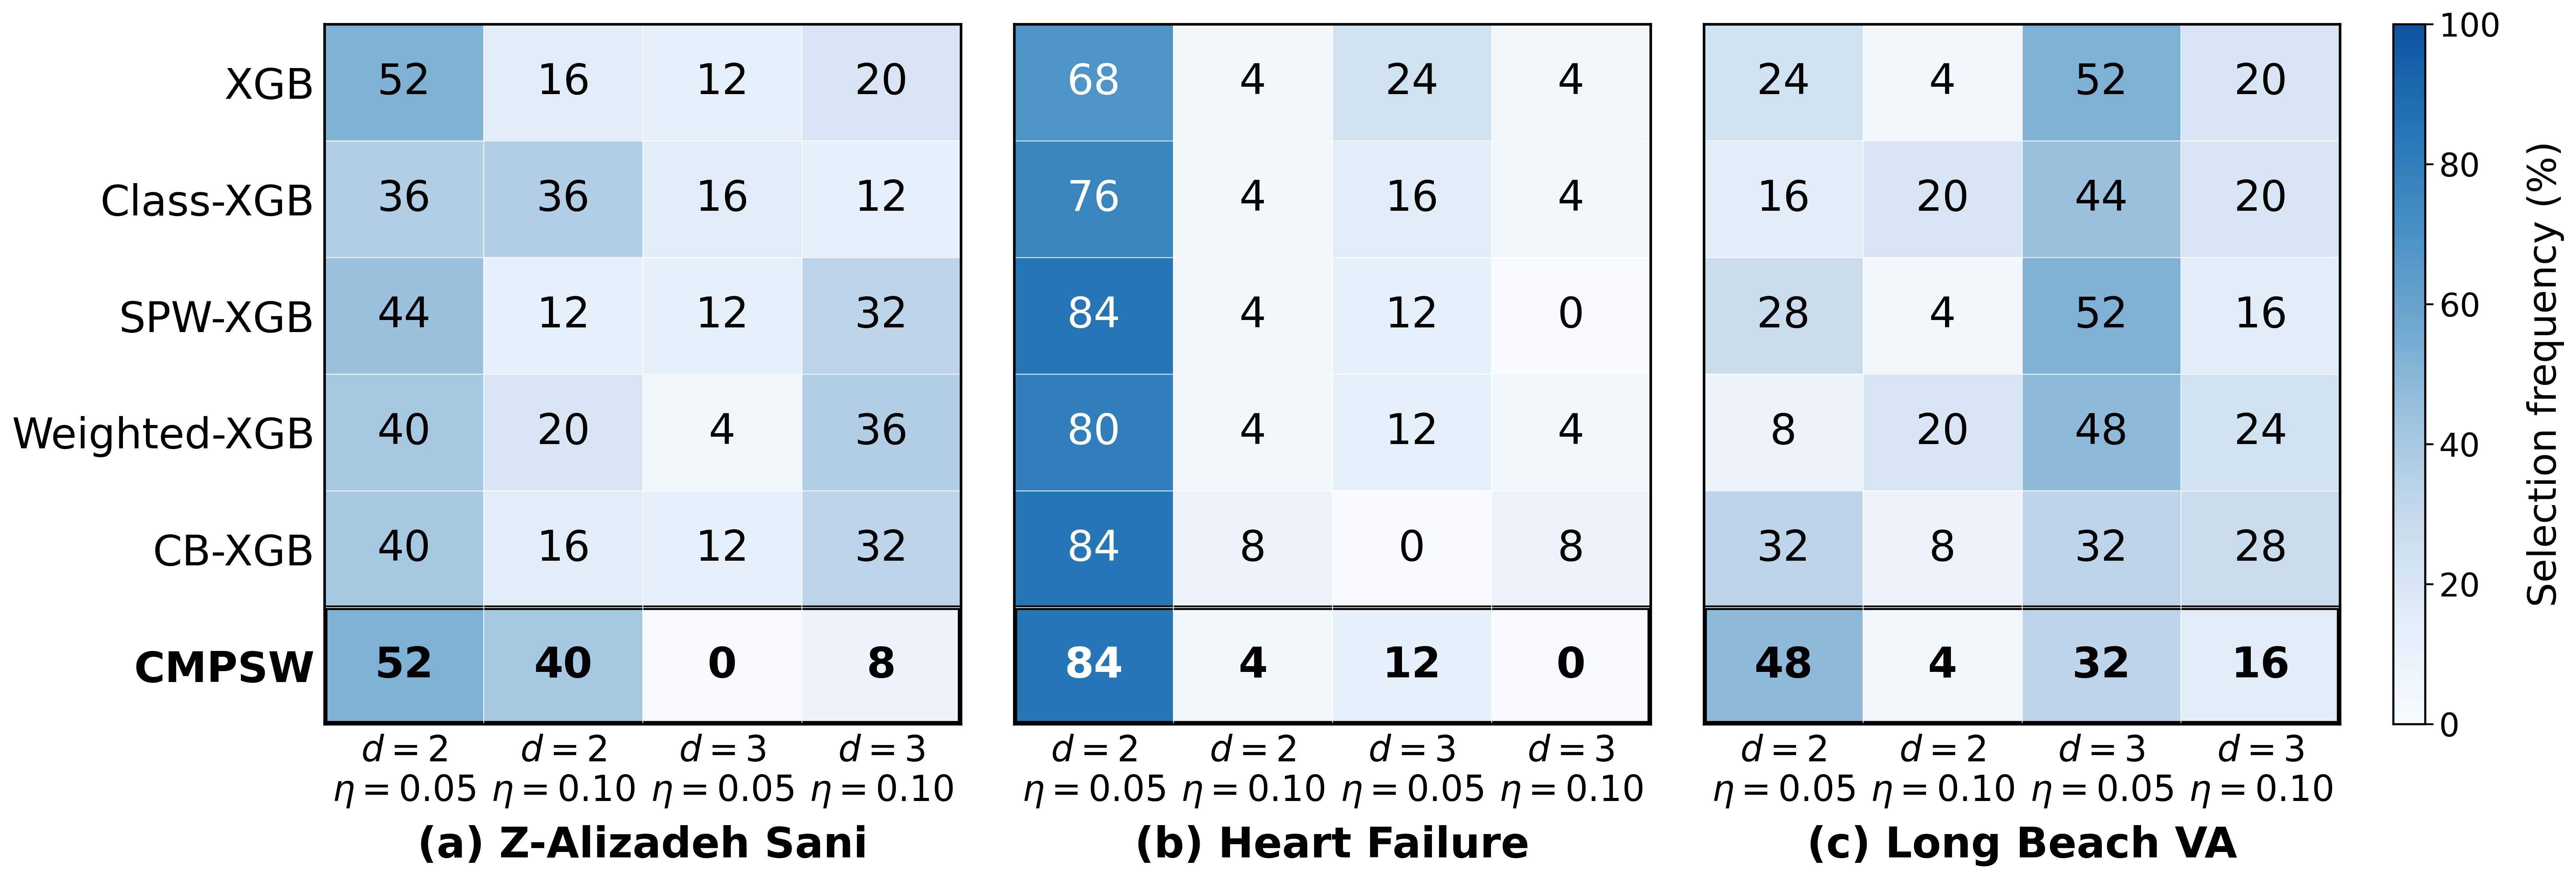

/content/drive/MyDrive/CMPSW_CODE_V1/figures/hyperparameter_selection_heatmap_300dpi.png
/content/drive/MyDrive/CMPSW_CODE_V1/figures/hyperparameter_selection_heatmap.pdf


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle


input_file = Path("/content/drive/MyDrive/CMPSW_CODE_V1/selected_parameters.csv")
output_dir = Path("/content/drive/MyDrive/CMPSW_CODE_V1/figures")
output_dir.mkdir(parents=True, exist_ok=True)

data = pd.read_csv(input_file)

datasets = [
    "Z-Alizadeh Sani",
    "Heart Failure",
    "Long Beach VA",
]

methods = [
    "XGB",
    "Class-XGB",
    "SPW-XGB",
    "Weighted-XGB",
    "CB-XGB",
    "CMPSW",
]

configs = [
    (2, 0.05),
    (2, 0.10),
    (3, 0.05),
    (3, 0.10),
]

config_labels = [
    r"$d=2$" + "\n" + r"$\eta=0.05$",
    r"$d=2$" + "\n" + r"$\eta=0.10$",
    r"$d=3$" + "\n" + r"$\eta=0.05$",
    r"$d=3$" + "\n" + r"$\eta=0.10$",
]

panel_labels = [
    "(a) Z-Alizadeh Sani",
    "(b) Heart Failure",
    "(c) Long Beach VA",
]

count_table = (
    data.groupby(["Dataset", "Method", "Depth", "Learning_Rate"])
    .size()
    .rename("Count")
    .reset_index()
)

total_table = (
    data.groupby(["Dataset", "Method"])
    .size()
    .rename("Total")
    .reset_index()
)

rows = []

for dataset in datasets:
    for method in methods:
        total_match = total_table[
            (total_table["Dataset"] == dataset) &
            (total_table["Method"] == method)
        ]
        total = int(total_match["Total"].iloc[0]) if not total_match.empty else 0

        for depth, rate in configs:
            match = count_table[
                (count_table["Dataset"] == dataset) &
                (count_table["Method"] == method) &
                (count_table["Depth"] == depth) &
                np.isclose(count_table["Learning_Rate"], rate)
            ]
            count = int(match["Count"].iloc[0]) if not match.empty else 0
            freq = 100.0 * count / total if total > 0 else 0.0

            rows.append({
                "Dataset": dataset,
                "Method": method,
                "Depth": depth,
                "Learning_Rate": rate,
                "Count": count,
                "Total": total,
                "Selection_Frequency": freq,
            })

plot_data = pd.DataFrame(rows)
plot_data.to_csv(output_dir / "hyperparameter_selection_frequency.csv", index=False)

colors = [
    "#f7fbff",
    "#e3eef8",
    "#c8dbec",
    "#9fc4df",
    "#6fa8cf",
    "#458fc4",
    "#2374b5",
    "#0b559f",
]

cmap = LinearSegmentedColormap.from_list("custom_blue", colors)

fig = plt.figure(figsize=(20, 7.5))
grid = fig.add_gridspec(
    1,
    4,
    width_ratios=[1, 1, 1, 0.05],
    wspace=0.11,
)

axes = [
    fig.add_subplot(grid[0, 0]),
    fig.add_subplot(grid[0, 1]),
    fig.add_subplot(grid[0, 2]),
]
cax = fig.add_subplot(grid[0, 3])

for i, (ax, dataset, panel_label) in enumerate(zip(axes, datasets, panel_labels)):
    matrix = np.zeros((len(methods), len(configs)), dtype=float)

    for r, method in enumerate(methods):
        for c, (depth, rate) in enumerate(configs):
            value = plot_data.loc[
                (plot_data["Dataset"] == dataset) &
                (plot_data["Method"] == method) &
                (plot_data["Depth"] == depth) &
                np.isclose(plot_data["Learning_Rate"], rate),
                "Selection_Frequency",
            ].iloc[0]
            matrix[r, c] = value

    image = ax.imshow(
        matrix,
        cmap=cmap,
        vmin=0,
        vmax=100,
        aspect="auto",
        interpolation="nearest",
    )

    ax.set_xticks(np.arange(len(config_labels)))
    ax.set_xticklabels(config_labels, fontsize=22, linespacing=1.15)

    ax.set_yticks(np.arange(len(methods)))
    if i == 0:
        ax.set_yticklabels(methods, fontsize=26)
        for label in ax.get_yticklabels():
            if label.get_text() == "CMPSW":
                label.set_fontweight("bold")
    else:
        ax.set_yticklabels([])

    for r in range(matrix.shape[0]):
        for c in range(matrix.shape[1]):
            value = matrix[r, c]
            text_color = "white" if value >= 60 else "black"
            ax.text(
                c,
                r,
                f"{value:.0f}",
                ha="center",
                va="center",
                fontsize=26,
                color=text_color,
                fontweight="bold" if methods[r] == "CMPSW" else "normal",
            )

    cmpsw_row = methods.index("CMPSW")
    ax.add_patch(
        Rectangle(
            (-0.495, cmpsw_row - 0.495),
            len(configs) - 0.01,
            0.99,
            fill=False,
            edgecolor="black",
            linewidth=2.8,
        )
    )

    for x in np.arange(-0.5, len(configs), 1):
        ax.axvline(x, linewidth=0.7, color="white", alpha=0.70)

    for y in np.arange(-0.5, len(methods), 1):
        ax.axhline(y, linewidth=0.7, color="white", alpha=0.70)

    ax.set_xlabel(
        panel_label,
        fontsize=26,
        fontweight="bold",
        labelpad=10,
    )

    ax.tick_params(axis="both", length=0, pad=6)

    for spine in ax.spines.values():
        spine.set_linewidth(1.6)

colorbar = fig.colorbar(image, cax=cax)
colorbar.set_ticks([0, 20, 40, 60, 80, 100])
colorbar.set_label("Selection frequency (%)", fontsize=24, labelpad=16)
colorbar.ax.tick_params(labelsize=20)
colorbar.outline.set_linewidth(1.3)

fig.subplots_adjust(
    left=0.05,
    right=0.95,
    bottom=0.18,
    top=0.98,
)

png_file = output_dir / "hyperparameter_selection_heatmap_300dpi.png"
pdf_file = output_dir / "hyperparameter_selection_heatmap.pdf"

fig.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    pdf_file,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print(png_file)
print(pdf_file)